In [10]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [11]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [12]:
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [13]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}  
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [24]:

block_size = 3
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X, device=device)
    Y = torch.tensor(Y, device=device)
    return X, Y

random.seed(47)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xtes, Ytes = build_dataset(words[n2:])

In [25]:
# Variable initialization
emb_dimension = 10
neurons_in_layer_1 = 200
learning_rate = 0.1

In [72]:
# mlp architecture
g = torch.Generator(device=device).manual_seed(2147483647)
C = torch.randn((vocab_size, emb_dimension), generator=g, device=device)
w1 = torch.randn((block_size*emb_dimension, neurons_in_layer_1), generator=g, device=device) * (5/3)/ ((block_size*emb_dimension)**0.5)
b1 = torch.randn(neurons_in_layer_1, generator=g, device=device)                    * 0.01
# w2 = torch.randn((neurons_in_layer_1, neurons_in_layer_2), generator=g)
# b2 = torch.randn(neurons_in_layer_2, generator=g)
w2 = torch.randn((neurons_in_layer_1, vocab_size), generator=g, device=device)      * 0.01
b2 = torch.randn(vocab_size, generator=g, device=device)                            * 0

bngain = torch.ones((1, neurons_in_layer_1), device=device)
bnbias = torch.zeros((1, neurons_in_layer_1), device=device)

parameters = [C, w1, b1, w2, b2, bngain, bnbias]

for p in parameters:
    p.requires_grad = True
    p.data = p.data.to(device)

In [73]:
batch_size = 32
epochs = 200000
lossi = []

for epoch in range(epochs): 

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    emb = C[Xb]
    formatted_input = emb.view(emb.shape[0], emb.shape[1]*emb.shape[2])
    h1 = formatted_input @ w1 + b1 
    h1 = bngain * (h1 - h1.mean(0, keepdim=True)) / (h1.std(0, keepdim=True) + 1e-5) + bnbias  # LayerNorm
    h1 = torch.tanh(h1)
    logits = h1 @ w2 + b2
    loss = F.cross_entropy(logits, Yb)
    lossi.append(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None  
    loss.backward()

    lr = 0.1 if epoch < 100000 else 0.01

    for p in parameters:
        p.data += -lr * p.grad

    if epoch % 10000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")
    break


Epoch 0, Loss: 3.2998


(array([  1.,   1.,   0.,   1.,   1.,   1.,   1.,   6.,  15.,  13.,  24.,
         36.,  73.,  68., 109., 134., 214., 223., 327., 342., 392., 448.,
        502., 452., 412., 383., 399., 337., 319., 249., 248., 190., 128.,
        102.,  94.,  48.,  44.,  27.,  11.,  11.,   6.,   2.,   2.,   0.,
          2.,   1.,   0.,   0.,   0.,   1.]),
 array([-0.22552611, -0.21595779, -0.20638948, -0.19682116, -0.18725284,
        -0.17768453, -0.16811621, -0.15854789, -0.14897958, -0.13941126,
        -0.12984294, -0.12027463, -0.11070631, -0.10113799, -0.09156968,
        -0.08200136, -0.07243304, -0.06286473, -0.05329641, -0.04372809,
        -0.03415978, -0.02459146, -0.01502314, -0.00545483,  0.00411349,
         0.01368181,  0.02325012,  0.03281844,  0.04238676,  0.05195507,
         0.06152339,  0.07109171,  0.08066002,  0.09022834,  0.09979666,
         0.10936497,  0.11893329,  0.12850161,  0.13806992,  0.14763824,
         0.15720656,  0.16677487,  0.17634319,  0.18591151,  0.19547982,
 

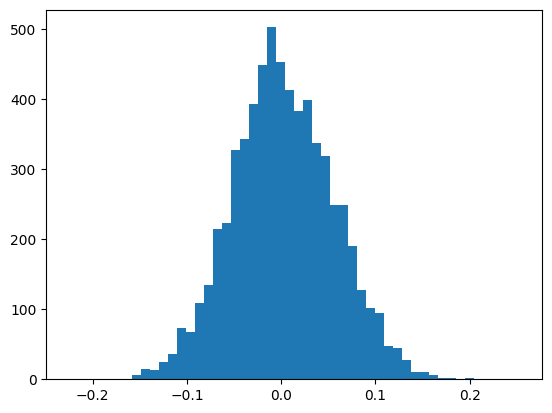

In [55]:
plt.hist(h1.view(-1).tolist(), 50)

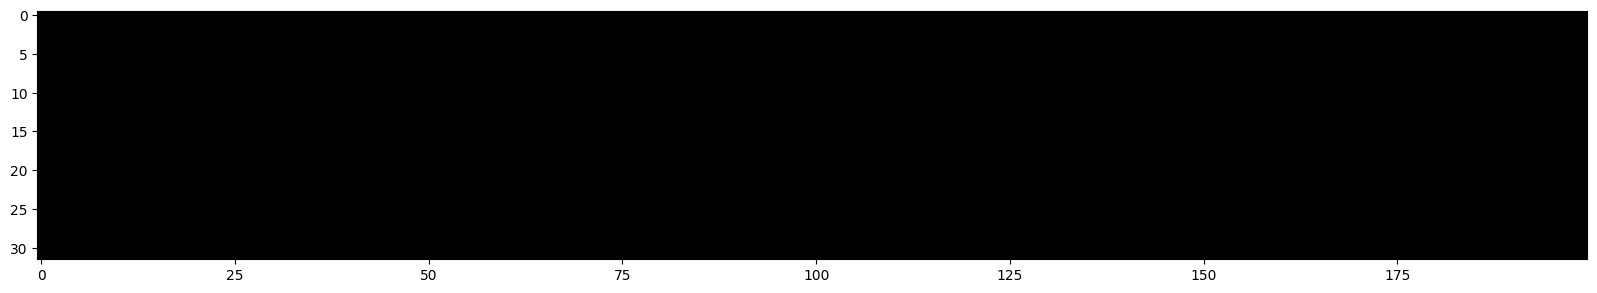

In [56]:
plt.figure(figsize=(20,50))
plt.imshow(h1.abs().cpu().detach() > 0.99, cmap='gray', interpolation='nearest')

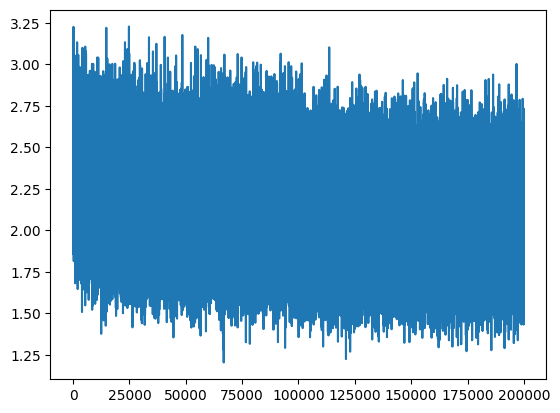

In [71]:
plt.plot(lossi)

In [ ]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xval, Yval),
        'test': (Xtes, Ytes)
    }[split]
    emb = C[x]
    formatted_input = emb.view(emb.shape[0], emb.shape[1]*emb.shape[2])
    h1 = formatted_input @ w1 + b1 
    h1 = bngain * (h1 - h1.mean(0, keepdim=True)) / (h1.std(0, keepdim=True) + 1e-5) + bnbias  # LayerNorm
    h1 = torch.tanh(h1)
    logits = h1 @ w2 + b2
    loss = F.cross_entropy(logits, y)
    print(f"{split} loss: {loss.item():.4f}")

split_loss('train')
split_loss('val')

train loss: 2.0512
val loss: 2.1202


In [ ]:
g = torch.Generator(device=device).manual_seed(2147483647)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context], device=device)]
        formatted_input = emb.view(emb.shape[0], emb.shape[1]*emb.shape[2])
        h1 = formatted_input @ w1 + b1 
        h1 = torch.tanh(h1)
        logits = h1 @ w2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))